# HULL-WHITE ONE-FACTOR MODEL

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

Bond Pricing Equation

$$ \frac{\partial p}{\partial t} + a_t \frac{\partial p}{\partial r_t} + \frac{1}{2}b_t^2 \frac{\partial^2 p}{\partial r_t^2} - r_t p = 0$$


Hull-White 1-Factor Interest Rate Model

$$ d r_t = a_t dt + b_t  d\tilde{W}_t =  \alpha (\mu(t) - r_t) dt + \sigma d\tilde{W}_t $$

## Calibrating the Model

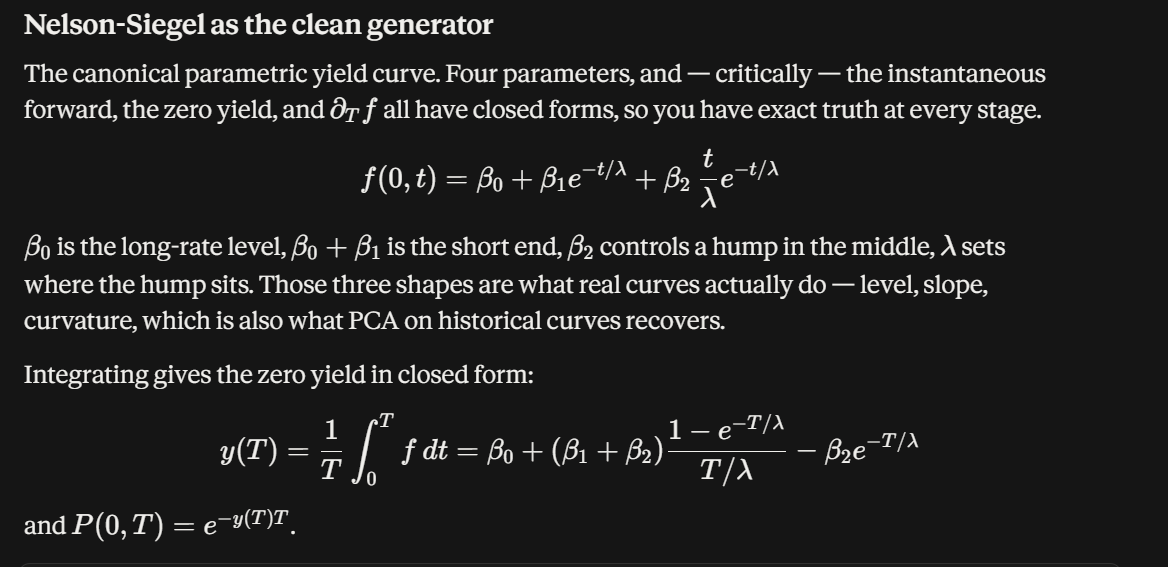

In [2]:


def ns_f(t, b0, b1, b2, lam):                 # instantaneous forward
    x = t/lam
    return b0 + b1*np.exp(-x) + b2*x*np.exp(-x)

def ns_fprime(t, b0, b1, b2, lam):            # df/dt, analytic
    x = t/lam
    return np.exp(-x)*(-b1/lam + b2/lam - b2*x/lam)

def ns_y(T, b0, b1, b2, lam):   #yield/averaging the forward rate over maturity time
    x = T/lam
    return b0 + (b1+b2)*(1-np.exp(-x))/x - b2*np.exp(-x)

def ns_P(T, b0, b1, b2, lam):  #analytical bond price today
    return np.exp(-ns_y(T, b0, b1, b2, lam)*T)


In [3]:
TRUE = dict(b0=0.045, b1=-0.020, b2=0.030, lam=1.5)
mats = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])   # maturity times

rng = np.random.default_rng(0)
y_obs = ns_y(mats, **TRUE) + rng.normal(0, 2e-4, len(mats))    # adding noise
P_obs = np.exp(-y_obs*mats)

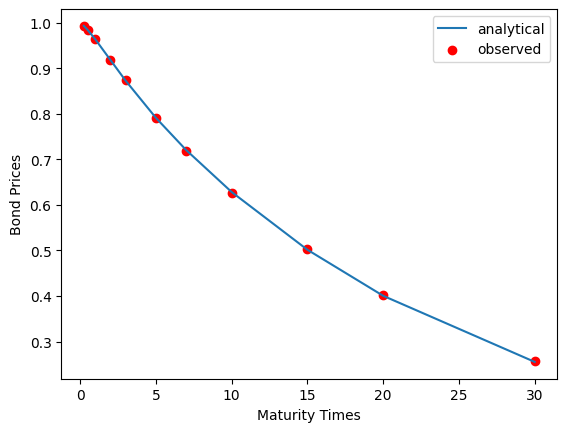

In [4]:
plt.plot(mats, ns_P(mats, **TRUE), label ='analytical')
plt.scatter(mats, P_obs, label ='observed', c='red')
plt.ylabel('Bond Prices')
plt.xlabel('Maturity Times')
plt.legend()
plt.show()

Let's say we observe the red line. 

We can always invert to get the market/real yield curve shown below

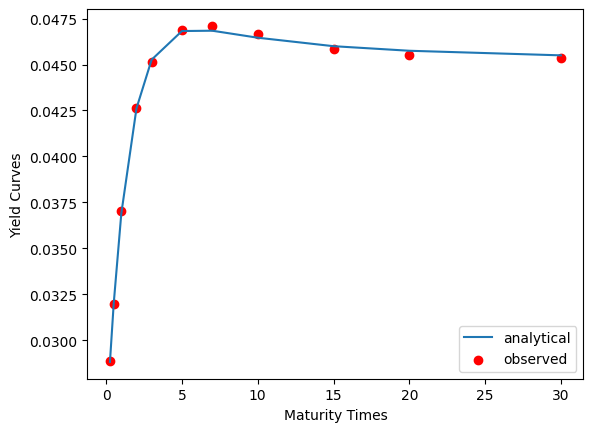

In [5]:
plt.plot(mats, ns_y(mats, **TRUE), label ='analytical')
plt.scatter(mats, y_obs, label ='observed', c='red')
plt.ylabel('Yield Curves')
plt.xlabel('Maturity Times')
plt.legend()
plt.show()

Now based on this observed yield curve, we fit for Nelson-Siegel parameters and get an 'observed' instantaneous forward rate

In [6]:
#function here

def ns_basis(T, lam):
    """
    Design matrix for Nelson-Siegel yields at a FIXED lam.

    y(T) = b0*1 + b1*s(T) + b2*(s(T) - exp(-T/lam)),   s(T) = (1-exp(-T/lam))/(T/lam)

    Columns are the level, slope and curvature factors. With lam held fixed the
    model is linear in (b0,b1,b2), which is the whole point: only lam is nonlinear.
    """
    x = T/lam
    s = (1 - np.exp(-x))/x
    return np.column_stack([np.ones_like(T), s, s - np.exp(-x)])


def fit_ns(T, y, lam_bounds=(0.2, 15.)):
    """
    Fit Nelson-Siegel to observed zero yields y at maturities T.

    Two-level structure, same trick as SVI:
      inner : with lam fixed, (b0,b1,b2) solve an ordinary linear least squares
              -- exact, one call, no starting guess needed
      outer : 1-D bounded search over lam only

    This is deterministic and seed-independent, unlike a 4-parameter nonlinear
    fit which has local minima and depends on where you start it.
    """
    def rss(lam):
        A = ns_basis(T, lam)
        b, *_ = np.linalg.lstsq(A, y, rcond=None)
        return np.sum((A @ b - y)**2)

    lam = scipy.optimize.minimize_scalar(rss, bounds=lam_bounds,
                          method='bounded', options={'xatol': 1e-10}).x

    A = ns_basis(T, lam)
    b, *_ = np.linalg.lstsq(A, y, rcond=None)
    return dict(b0=b[0], b1=b[1], b2=b[2], lam=lam)

In [7]:
ns_fit_vals = fit_ns(mats, y_obs)

In [8]:
ns_fit_vals

{'b0': 0.04468919023942636,
 'b1': -0.019514911151035732,
 'b2': 0.031409482577280316,
 'lam': 1.5736805287044329}

In [9]:
TRUE

{'b0': 0.045, 'b1': -0.02, 'b2': 0.03, 'lam': 1.5}

Then based on fitted values, get the Hull-White $\mu(t)$

In [10]:

def mu(t):
    return ns_f(t, **ns_fit_vals) + ns_fprime(t, **ns_fit_vals)/alpha + sig**2/(2*alpha**2)*(1 - np.exp(-2*alpha*t))
#alpha defined below


In [11]:
r0 = ns_f(0., **ns_fit_vals)

In [12]:
r0, ns_f(0, **TRUE) #this is the fitted instantaneous forward rate now, compared to the analytical value

(0.025174279088390625, 0.024999999999999998)

## PDE Solver. Here we will see how well the numerics give back the market values

$ \tau := T - t$

$$\frac{\partial p}{\partial \tau} = a_t \frac{\partial p}{\partial r_t} + \frac{1}{2}b_t^2 \frac{\partial^2 p}{\partial r_t^2} - r_t p$$

In [109]:
T = mats[7] #maturity time

#params in vasicek model
alpha = 0.5

sig = 0.01


rmin = -0.4

rmax = 0.4

In [110]:
n = 50 #grid resolution

diff = np.loadtxt('diffmatrix100.txt')[0:n,0:n]

chebyshevs = []
for i in range(0, n):
    chebyshevs.append(scipy.special.chebyt(i))

In [111]:
# tau array

tau = np.linspace(0, T, int(T/10**-3 + 1))
dtau = tau[1:] - tau[0:-1]

# solution array

c = np.zeros((len(tau), n))

#match to terminal condition

#coefficient of T_0 matched to unity at tau = 0!
c[0,0] = 1.

In [112]:
# transform to numerical coordinates

def xnum_to_r(xnum):
    return rmax + (xnum - 1.)*((rmax - rmin)/2) 

In [113]:
# functions to plot data

xplot = np.linspace(-1,1,101)

def calc_u(c,x):
    sum = 0.0
    for i in range(len(c)):
        sum = sum + c[i]*chebyshevs[i](x)
    return sum

def plot_frame(tau_index):

    #left part
  
    plt.plot(xnum_to_r(xplot), calc_u(c[tau_index,:], xplot), c='blue')
       
    plt.title('p(x) at '+r'$\tau=$ '+str(tau[tau_index]))
    plt.ylabel(r'$p$')
    plt.xlabel(r'$x$')
    plt.show()

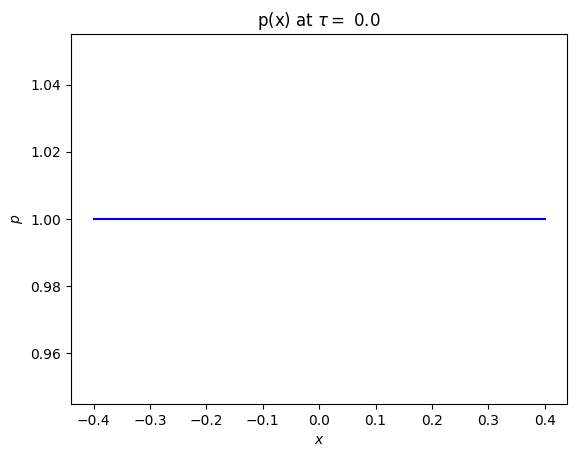

In [114]:
plot_frame(0)

In [115]:
a11 = 4.772644573858262e-01
c1 = a11

a21 = -1.970525884150017e-01
a22 = 4.763634284595835e-01
c2 = a21 + a22

a31 = -3.476744303729656e-02
a32 = 6.330518073354831e-01
a33 = 1.936343100750279e-01
c3 = a31 + a32 + a33

a41 = 9.677976685787021e-02
a42 = -1.935335264665350e-01
a43 = -2.076229458004729e-04
a44 = 1.595722048494314e-01
c4 = a41 + a42 + a43 + a44

a51 = 1.625272318198749e-01
a52 = -2.496725135473825e-01
a53 = -4.590799720417948e-02
a54 = 3.657947640085904e-01
a55 = 2.557528383076989e-01
c5 = a51 + a52 + a53 + a54 + a55

a61 = -7.076031971712624e-03
a62 = 8.462998548602952e-01
a63 = 3.440200169250181e-01
a64 = -7.209260545488652e-02
a65 = -2.154923319808753e-01
a66 = 1.043410976221611e-01
c6 = a61 + a62 + a63 + a64 + a65 + a66


a71 = 1.768579351797444e-03
a72 = 7.799600131275149e-02
a73 = 3.033332775645574e-01
a74 = 2.131608067328356e-01
a75 = 3.517693203190381e-01
a76 = -3.815458943865381e-01
a77 = 4.335179091055582e-01
c7 = a71 + a72 + a73 + a74 + a75 + a76 + a77

a81 = 0.000000000000000e+00
a82 = 2.273235341055902e-01
a83 = 3.084158379801177e-01
a84 = 1.572634195730069e-01
a85 = 2.435511371522748e-01
a86 = -1.209536267328315e-01
a87 = -8.026784733998993e-02
a88 =  2.646675452618318e-01
c8 = a81 + a82 + a83 + a84 + a85 + a86 + a87 + a88

b1 = a81
b2 = a82
b3 = a83
b4 = a84
b5 = a85
b6 = a86
b7 = a87
b8 = a88

In [116]:
def calc_T_matrix(dim, xcol):
    T = np.zeros(dim)
    for i in range(0,dim):
        T[i] = chebyshevs[i](xcol)
    return T

#Gauss-Lobatto Nodes
xcol = np.cos(np.pi*np.linspace(1, n-2, int(n-2))/(n-1))

#collocation matrices
Tcol = np.zeros((len(xcol),n))
for i in range(0, len(xcol)):
    Tcol[i,:] = calc_T_matrix(n, xcol[i])
    
Tdiffcol = np.matmul(Tcol, diff)
Tdiff2col = np.matmul(np.matmul(Tcol, diff), diff)

In [117]:
def calc_K(c, tau_inp, dtau_inp, K1, K2, K3, K4, K5, K6, K7, key):

    dtau = dtau_inp

    if key == 1:
        tau = tau_inp + dtau*c1
    elif key == 2:
        tau = tau_inp + dtau*c2
    elif key == 3:
        tau = tau_inp + dtau*c3
    elif key == 4:
        tau = tau_inp + dtau*c4
    elif key == 5:
        tau = tau_inp + dtau*c5
    elif key == 6:
        tau = tau_inp + dtau*c6
    elif key == 7:
        tau = tau_inp + dtau*c7
    elif key == 8:
        tau = tau_inp + dtau*c8
    

    L = np.zeros((n, n))
    R = np.zeros((n, n))
    J = np.zeros(n)
    
    #prepare the matrices
    
###################################################################################################
  
    #PDE

    rcol = xnum_to_r(xcol)
    L[0:len(xcol),:] = Tcol 
    R[0:len(xcol),:] = (1/2)*sig**2*(2/(rmax - rmin))**2*Tdiff2col + (alpha*(mu(T - tau) - rcol)*(2/(rmax - rmin))*Tdiffcol.T).T + ((-rcol)*Tcol.T).T
    
    row_count = len(xcol)    
        
#############################################################################################################################################
    
    #boundary conditions
    
    Bt = (1. - np.exp(-alpha*tau))/alpha
    scale = 2./(rmax - rmin)

    # left boundary: dp/dr + B*p = 0
    R[row_count, :] = scale*calc_T_matrix(n, -1.) @ diff + Bt*calc_T_matrix(n, -1.)
    J[row_count] = 0.
    row_count += 1

    # right boundary
    R[row_count, :] = scale*calc_T_matrix(n, +1.) @ diff + Bt*calc_T_matrix(n, +1.)
    J[row_count] = 0.
    row_count += 1

    
    
####################################################################################################################################################
    
    if key == 1:
        Lbar = L - R*(dtau)*(a11)
        Rbar = np.matmul(R, c) - J
        K1 = np.linalg.solve(Lbar,Rbar)
        return K1
    elif key == 2:
        Lbar = L - R*(dtau)*(a22)
        Rbar = np.matmul(R, c + dtau*K1*a21) - J
        K2 = np.linalg.solve(Lbar,Rbar)
        return K2
    elif key == 3:
        Lbar = L - R*(dtau)*(a33)
        Rbar = np.matmul(R, c + dtau*K1*a31 + dtau*K2*a32) - J
        K3 = np.linalg.solve(Lbar,Rbar)
        return K3
    elif key == 4:
        Lbar = L - R*(dtau)*(a44)
        Rbar = np.matmul(R, c + dtau*K1*a41 + dtau*K2*a42 + dtau*K3*a43) - J
        K4 = np.linalg.solve(Lbar,Rbar)
        return K4
    elif key == 5:
        Lbar = L - R*(dtau)*(a55)
        Rbar = np.matmul(R, c + dtau*K1*a51 + dtau*K2*a52 + dtau*K3*a53 + dtau*K4*a54) - J
        K5 = np.linalg.solve(Lbar,Rbar)
        return K5
    elif key == 6:
        Lbar = L - R*(dtau)*(a66)
        Rbar = np.matmul(R, c + dtau*K1*a61 + dtau*K2*a62 + dtau*K3*a63 + dtau*K4*a64 + dtau*K5*a65) - J
        K6 = np.linalg.solve(Lbar,Rbar)
        return K6
    elif key == 7:
        Lbar = L - R*(dtau)*(a77)
        Rbar = np.matmul(R, c + dtau*K1*a71 + dtau*K2*a72 + dtau*K3*a73 + dtau*K4*a74 + dtau*K5*a75 + dtau*K6*a76) - J
        K7 = np.linalg.solve(Lbar,Rbar)
        return K7
    elif key == 8:
        Lbar = L - R*(dtau)*(a88)
        Rbar = np.matmul(R, c + dtau*K1*a81 + dtau*K2*a82 + dtau*K3*a83 + dtau*K4*a84 + dtau*K5*a85 + dtau*K6*a86 + dtau*K7*a87) - J
        K8 = np.linalg.solve(Lbar,Rbar)
        return K8
    

In [118]:
#Calculate Data for all Times

for i in range(0, len(tau)-1):
    K1 = calc_K(c[i,:],tau[i], dtau[i], None, None, None, None, None, None, None, 1)
    K2 = calc_K(c[i,:],tau[i], dtau[i], K1, None, None, None, None, None, None, 2)
    K3 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, None, None, None, None, None, 3)
    K4 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, None, None, None, None, 4)
    K5 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , None, None, None, 5)
    K6 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, None, None, 6)
    K7 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, K6, None, 7)
    K8 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, K6, K7, 8)

    c[i+1,:] = c[i,:] + dtau[i]*(b1*K1 + b2*K2 +b3*K3 + b4*K4 + b5*K5 + b6*K6 + b7*K7 + b8*K8)
    
    if i%100==0:
        print(i)
        print('The time is: '+str(tau[i]))
        print('The average of the Chebychev coefficients is: '+str(np.mean(np.abs(c[i,:]))))

0
The time is: 0.0
The average of the Chebychev coefficients is: 0.02
100
The time is: 0.1
The average of the Chebychev coefficients is: 0.020793457879842915
200
The time is: 0.2
The average of the Chebychev coefficients is: 0.02157269331453008
300
The time is: 0.3
The average of the Chebychev coefficients is: 0.02233612402813295
400
The time is: 0.4
The average of the Chebychev coefficients is: 0.023082333632668393
500
The time is: 0.5
The average of the Chebychev coefficients is: 0.02381006917988395
600
The time is: 0.6
The average of the Chebychev coefficients is: 0.02451823721973072
700
The time is: 0.7000000000000001
The average of the Chebychev coefficients is: 0.02520589860604038
800
The time is: 0.8
The average of the Chebychev coefficients is: 0.025872262276689068
900
The time is: 0.9
The average of the Chebychev coefficients is: 0.02651667821973793
1000
The time is: 1.0
The average of the Chebychev coefficients is: 0.027138629819547098
1100
The time is: 1.1
The average of the

## Analysis

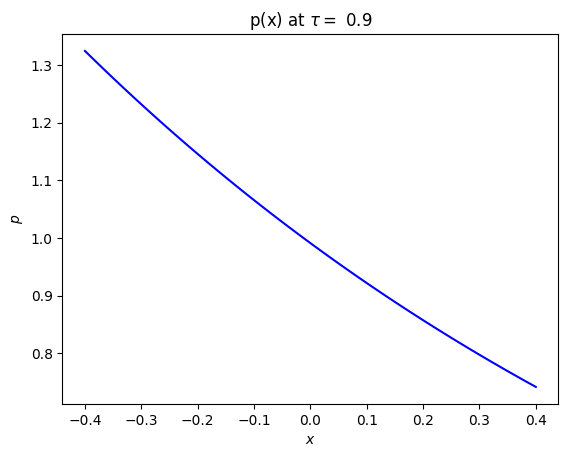

In [80]:
plot_frame(900)

In [81]:
def plot_coeff(tau_index):
    plt.plot(np.log10(np.abs(c[tau_index, :])), c='red')
    plt.xlabel(r'$k$')
    plt.ylabel(r'$log_{10}|c_k|$')
    plt.show()

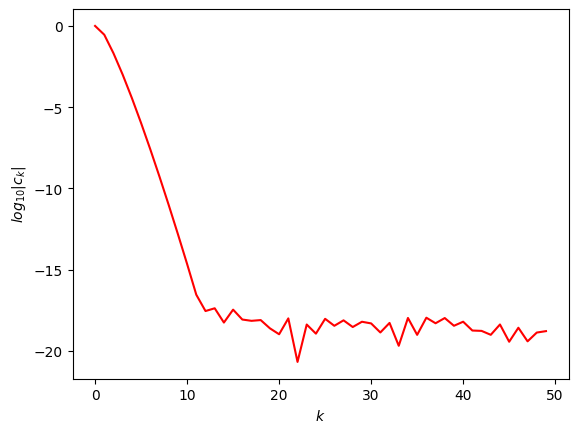

In [82]:
plot_coeff(901)

## Back-Test

In [40]:
P_obs, mats, ns_P(mats, **ns_fit_vals)

(array([0.99281549, 0.98413632, 0.9636527 , 0.91826232, 0.87330676,
        0.7909857 , 0.7191324 , 0.62719782, 0.50264673, 0.40254946,
        0.2563375 ]),
 array([ 0.25,  0.5 ,  1.  ,  2.  ,  3.  ,  5.  ,  7.  , 10.  , 15.  ,
        20.  , 30.  ]),
 array([0.99280322, 0.98411774, 0.96381587, 0.91831102, 0.87284296,
        0.79070142, 0.71982212, 0.62811535, 0.50206756, 0.40151913,
        0.25681637]))

So the third entry is the value our PDE solution at $r=r_0$ should recover well

In [26]:
def r_to_xnum(r):
    return 2*(r - rmax)/(rmax - rmin) + 1 

In [27]:
P_PDE = []


In [119]:
P_PDE.append(calc_u(c[-1,:], r_to_xnum(r0)))

In [120]:
P_PDE

[0.9928032157291286,
 0.984117743595822,
 0.9638158697307173,
 0.9183110217854247,
 0.8728429581794486,
 0.7907014172577564,
 0.7198221153648027,
 0.6281153537815055]

In [121]:
P_PDE = np.array(P_PDE)

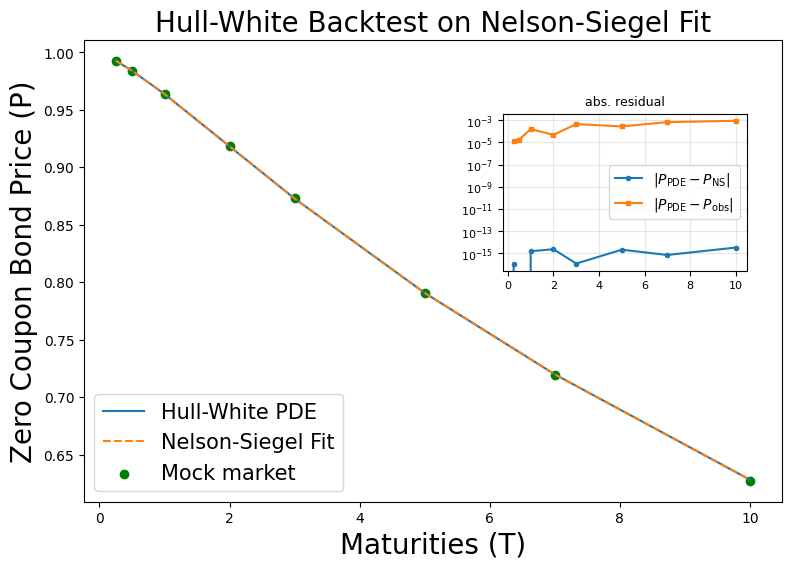

In [144]:
fig, ax = plt.subplots(figsize=(9, 6))

m = mats[0:8]
ax.plot(m, P_PDE, label='Hull-White PDE')
ax.plot(m, ns_P(m, **ns_fit_vals), linestyle='dashed', label='Nelson-Siegel Fit')
ax.scatter(m, P_obs[0:8], c='green', label='Mock market')
ax.set_xlabel('Maturities (T)', fontsize=20)
ax.set_ylabel('Zero Coupon Bond Price (P)', fontsize=20)
ax.set_title('Hull-White Backtest on Nelson-Siegel Fit', fontsize=20)
ax.legend(fontsize=15, loc=3)

# inset: [left, bottom, width, height] in axes fraction
axi = ax.inset_axes([0.6, 0.5, 0.35, 0.34])

axi.semilogy(m, np.abs(P_PDE - ns_P(m, **ns_fit_vals)), 'o-', ms=3,
             label=r'$|P_{\rm PDE}-P_{\rm NS}|$')
axi.semilogy(m, np.abs(P_PDE - P_obs[0:8]), 's-', ms=3,
             label=r'$|P_{\rm PDE}-P_{\rm obs}|$')
axi.set_title('abs. residual', fontsize=9)
axi.tick_params(labelsize=8)
axi.legend(fontsize=10, loc='center right')
axi.grid(alpha=0.3, which='both')

plt.show()